In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import glob, time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
jax.clear_caches()
import jax.numpy as jnp

import discovery as ds
from enterprise_extensions import load_feathers
from discovery.deterministic import make_phase_connected_binary
from discovery import const as disco_const
from discovery.deterministic import fpcmu_fast

print('Imports OK')

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


Imports OK


In [2]:
feather_dir = "../data_products/"
Npulsars = 5

disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:Npulsars]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float32)
print(f"Loaded {len(disco_psrs)} pulsars: {[p.name for p in disco_psrs]}")

psrs_ent = load_feathers.load_feathers_from_folder(feather_dir)
ent_by_name = {p.name: p for p in psrs_ent}

dist_mu = []
dist_sig = []
for psr in disco_psrs:
    ep = ent_by_name[psr.name]
    mu = float(ep.pdist[0])
    sig = float(ep.pdist[1]) if len(ep.pdist) > 1 else 0.5
    if (not np.isfinite(sig)) or sig <= 0:
        sig = 0.5
    dist_mu.append(mu)
    dist_sig.append(sig)

dist_mu = jnp.array(dist_mu, dtype=jnp.float64)
dist_sig = jnp.array(dist_sig, dtype=jnp.float64)

psr_toas_list = [np.asarray(psr.toas, dtype=np.float64) for psr in disco_psrs]
psr_pos_list = [psr.pos for psr in disco_psrs]
psr_positions = jnp.array([psr.pos for psr in disco_psrs])

sigma_toa = 1e-6
KPC_OVER_C = disco_const.kpc / disco_const.c

pnames_13 = (['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
              'log10_h', 'phase0', 'psi'] +
             [psr.name + '_dist' for psr in disco_psrs])

print(f"dist_mu: {[f'{float(d):.3f}' for d in dist_mu]}")
print(f"dist_sig: {[f'{float(d):.4f}' for d in dist_sig]}")

Loaded 5 pulsars: ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451']
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdi

In [3]:
# --- CW injection + log-posterior ---
INJ = {
    "cos_gwtheta": 0.3, "gwphi": 2.5, "cos_inc": -0.2,
    "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
    "phase0": 1.0, "psi": 0.7,
}

cw_func = make_phase_connected_binary(pulsarterm=True)

@jax.jit
def compute_delta_L(cos_gwtheta, gwphi, log10_fgw):
    gwtheta = jnp.arccos(cos_gwtheta)
    f_gw = 10.0 ** log10_fgw
    _, _, cos_mu = jax.vmap(
        lambda pos: fpcmu_fast(pos, gwtheta, gwphi)
    )(psr_positions)
    denom = jnp.abs(1.0 - cos_mu)
    denom = jnp.maximum(denom, 1e-4)
    return 1.0 / (f_gw * KPC_OVER_C * denom)

# Inject with distances offset from prior mean
DIST_OFFSET_SIGMA = 0.3
p5_true_dists = {}
for i, psr in enumerate(disco_psrs):
    p5_true_dists[psr.name] = float(dist_mu[i]) + DIST_OFFSET_SIGMA * float(dist_sig[i])

p5_data_list = []
for i, psr in enumerate(disco_psrs):
    toas_i = np.asarray(psr.toas, dtype=np.float64)
    delay_i = cw_func(toas_i, psr.pos, p_dist=p5_true_dists[psr.name], **INJ)
    p5_data_list.append(np.array(delay_i, dtype=np.float64))

INJ_vals = [INJ[k] for k in ['cos_gwtheta','gwphi','cos_inc','log10_mc','log10_fgw','log10_h','phase0','psi']]
p5_dist_vals = [p5_true_dists[psr.name] for psr in disco_psrs]
p5_truth = np.array(INJ_vals + p5_dist_vals)

sd_arr = np.array([float(dist_sig[i]) for i in range(Npulsars)])

# Log-posterior (physical space, no transforms)
sd_jnp = jnp.array(sd_arr, dtype=jnp.float64)
data_jnp = [jnp.array(d) for d in p5_data_list]

@jax.jit
def logp(x):
    p_dists = x[8:13]
    in_bounds = (
        (x[0] >= -1) & (x[0] <= 1) &
        (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
        (x[2] >= -1) & (x[2] <= 1) &
        (x[3] >= 7) & (x[3] <= 10) &
        (x[4] >= -9) & (x[4] <= -7) &
        (x[5] >= -18) & (x[5] <= -11) &
        (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
        (x[7] >= 0) & (x[7] <= jnp.pi) &
        jnp.all(p_dists > 1e-6)
    )
    ll = 0.0
    for p_idx in range(5):
        model = cw_func(
            psr_toas_list[p_idx], psr_pos_list[p_idx],
            cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
            log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
            phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
        )
        resid = data_jnp[p_idx] - model
        ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
    log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
    return jnp.where(in_bounds, ll + log_prior, -1e30)

# Mode spacing at truth
dL_truth = np.array(compute_delta_L(INJ['cos_gwtheta'], INJ['gwphi'], INJ['log10_fgw']))

# Sanity
lp_truth = float(logp(jnp.array(p5_truth)))
print(f"logp(truth) = {lp_truth:.2f}")
for i, psr in enumerate(disco_psrs):
    print(f"  {psr.name}: d_true={p5_dist_vals[i]:.4f}, dL={dL_truth[i]:.6f}, "
          f"modes/sig={float(dist_sig[i])/dL_truth[i]:.0f}")

logp(truth) = -0.23
  B1855+09: d_true=1.2160, dL=0.000580, modes/sig=207
  B1937+21: d_true=3.1600, dL=0.000583, modes/sig=343
  B1953+29: d_true=4.9190, dL=0.000603, modes/sig=1542
  J0023+0923: d_true=1.0530, dL=0.000591, modes/sig=186
  J0030+0451: d_true=0.3307, dL=0.000587, modes/sig=6


In [4]:
# ============================================================
# Compute Fisher information at truth
# The key insight: curvature within a mode is ~the same for all
# modes, so we compute once and reuse everywhere.
# ============================================================
print("Computing Hessian at truth...")
t0 = time.time()
H_full = np.array(jax.hessian(logp)(jnp.array(p5_truth)))
dt = time.time() - t0
print(f"  Hessian computed in {dt:.1f}s")
print(f"  H finite: {np.all(np.isfinite(H_full))}")
print(f"  H diag: {np.diag(H_full)}")

# Extract the 8x8 CW sub-block
H_cw = H_full[:8, :8]
neg_H_cw = -H_cw
eig_cw, evec_cw = np.linalg.eigh(neg_H_cw)
print(f"\n  CW block eigenvalues: {eig_cw}")
print(f"  All positive: {np.all(eig_cw > 0)}")

# CW proposal covariance = (-H_cw)^{-1} scaled by 2.38^2/d
eig_cw_c = np.maximum(eig_cw, 1e-12 * eig_cw.max())
cov_cw = evec_cw @ np.diag(1.0 / eig_cw_c) @ evec_cw.T
cov_cw = 0.5 * (cov_cw + cov_cw.T)
scale_cw = 2.38**2 / 8
L_cw = np.linalg.cholesky(scale_cw * cov_cw)
print(f"\n  CW Cholesky proposal widths (diag): {np.diag(L_cw)}")

# Per-pulsar distance Fisher widths (marginal from diagonal)
dist_fisher_sig = np.zeros(Npulsars)
for j in range(Npulsars):
    neg_hess_jj = -H_full[8+j, 8+j]
    if neg_hess_jj > 0:
        dist_fisher_sig[j] = 1.0 / np.sqrt(neg_hess_jj)
    else:
        dist_fisher_sig[j] = dL_truth[j] * 0.3  # fallback: fraction of mode spacing
    print(f"  {disco_psrs[j].name}: Fisher sig_d = {dist_fisher_sig[j]:.6f}, "
          f"dL = {dL_truth[j]:.6f}, ratio = {dist_fisher_sig[j]/dL_truth[j]:.2f}")

print(f"\nFisher setup complete")

Computing Hessian at truth...
  Hessian computed in 14.0s
  H finite: True
  H diag: [-5.45740660e+11 -2.10872292e+11 -1.77151447e+04 -2.40968167e+11
 -1.40474342e+13 -5.93184445e+04 -1.11661155e+04 -2.40552100e+04
 -8.19695407e+10 -1.87274085e+11 -5.46993855e+10 -4.24218891e+10
 -1.20613374e+11]

  CW block eigenvalues: [6.90991437e+02 2.42456760e+03 1.61973609e+04 6.38987584e+04
 3.42348882e+06 2.30493613e+10 3.22600784e+10 1.49897025e+13]
  All positive: True

  CW Cholesky proposal widths (diag): [4.83551305e-04 7.54053071e-06 1.07300882e-02 8.47237579e-06
 3.42520403e-07 4.46419819e-03 1.12364854e-02 5.42534534e-03]
  B1855+09: Fisher sig_d = 0.000003, dL = 0.000580, ratio = 0.01
  B1937+21: Fisher sig_d = 0.000002, dL = 0.000583, ratio = 0.00
  B1953+29: Fisher sig_d = 0.000004, dL = 0.000603, ratio = 0.01
  J0023+0923: Fisher sig_d = 0.000005, dL = 0.000591, ratio = 0.01
  J0030+0451: Fisher sig_d = 0.000003, dL = 0.000587, ratio = 0.00

Fisher setup complete


In [5]:
# ============================================================
# Blocked MCMC sampler
#   Move A (40%): CW-only 8D Fisher jump (distances unchanged)
#   Move B (15%): Single-pulsar within-mode distance refinement
#   Move C (15%): Big distance jump (integer mode hop)
#   Move D (15%): Small distance perturbation (fraction of dL)
#   Move E (15%): Single CW param Gibbs
# ============================================================

def ess_1d(x, max_lag=500):
    n = len(x)
    x = x - x.mean()
    var = np.var(x)
    if var < 1e-30:
        return 1.0
    acf = np.correlate(x, x, mode='full')[n-1:n-1+max_lag+1] / (n * var)
    cutoff = np.argmax(acf < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    tau = 1.0 + 2.0 * np.sum(acf[1:cutoff])
    return n / max(tau, 1.0)

def run_blocked_chain(logp_fn, x0, rng, L_cw, dist_fisher_sig, dL_arr,
                      n_burn=2000, n_prod=5000, report_every=1000):
    D = len(x0)
    Npsr = D - 8
    x = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))
    
    chain = np.zeros((n_prod, D))
    lps = np.zeros(n_prod)
    
    # Acceptance counters per move type
    acc = {'cw_fisher': 0, 'dist_within': 0, 'dist_big': 0,
           'dist_small': 0, 'cw_gibbs': 0}
    tot = {'cw_fisher': 0, 'dist_within': 0, 'dist_big': 0,
           'dist_small': 0, 'cw_gibbs': 0}
    
    # CW Gibbs step sizes from Fisher diagonal
    cw_gibbs_sig = np.diag(L_cw).copy()
    
    total_steps = n_burn + n_prod
    t0 = time.time()
    
    for step in range(-n_burn, n_prod):
        r = rng.random()
        
        if r < 0.40:
            # Move A: CW-only 8D Fisher jump
            z = rng.standard_normal(8)
            x_prop = x.copy()
            x_prop[:8] += L_cw @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_fisher'] += 1
            tot['cw_fisher'] += 1
            
        elif r < 0.55:
            # Move B: Within-mode distance refinement (one pulsar)
            pi = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1
            
        elif r < 0.70:
            # Move C: Big distance jump (integer mode hop)
            pi = rng.integers(Npsr)
            n_modes = rng.integers(1, 20)
            sign = rng.choice([-1, 1])
            x_prop = x.copy()
            x_prop[8+pi] += sign * n_modes * float(dL_arr[pi])
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_big'] += 1
            tot['dist_big'] += 1
            
        elif r < 0.85:
            # Move D: Small distance perturbation (fraction of dL)
            pi = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += 0.3 * float(dL_arr[pi]) * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_small'] += 1
            tot['dist_small'] += 1
            
        else:
            # Move E: Single CW param Gibbs
            idx = rng.integers(8)
            x_prop = x.copy()
            x_prop[idx] += cw_gibbs_sig[idx] * rng.standard_normal()
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_gibbs'] += 1
            tot['cw_gibbs'] += 1
        
        if step >= 0:
            chain[step] = x
            lps[step] = lp
        
        # Update dL periodically (sky/fgw may have moved)
        abs_step = step + n_burn
        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))
        
        # Progress report
        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            ar_str = '  '.join(f"{k}={acc[k]/max(tot[k],1):.3f}" for k in acc)
            rate = abs_step / elapsed
            eta = (total_steps - abs_step) / rate
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f}  "
                  f"AR: {ar_str}  [{rate:.0f} it/s, ETA {eta:.0f}s]")
    
    dt_total = time.time() - t0
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    ar_dict = {k: acc[k]/max(tot[k],1) for k in acc}
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    
    return chain, lps, ar_dict

print("Blocked sampler defined")

Blocked sampler defined


In [6]:
# ============================================================
# Quick test: start from truth, short chain
# Goal: verify CW Fisher acceptance is non-zero
# ============================================================
print("Test 1: Start from truth (2k burn + 5k prod)")
print(f"  logp(truth) = {lp_truth:.2f}")

dL_start = np.array(compute_delta_L(
    p5_truth[0], p5_truth[1], p5_truth[4]))

chain, lps_chain, ar = run_blocked_chain(
    logp, p5_truth.copy(), np.random.default_rng(42),
    L_cw=L_cw, dist_fisher_sig=dist_fisher_sig, dL_arr=dL_start,
    n_burn=2000, n_prod=5000, report_every=1000)

Test 1: Start from truth (2k burn + 5k prod)
  logp(truth) = -0.23
  [burn 1000/7000] lp=-4.23  AR: cw_fisher=0.236  dist_within=0.679  dist_big=0.007  dist_small=0.025  cw_gibbs=0.530  [1919 it/s, ETA 3s]
  [prod 2000/7000] lp=-5.60  AR: cw_fisher=0.235  dist_within=0.678  dist_big=0.003  dist_small=0.037  cw_gibbs=0.503  [2023 it/s, ETA 2s]
  [prod 3000/7000] lp=-3.69  AR: cw_fisher=0.228  dist_within=0.704  dist_big=0.002  dist_small=0.037  cw_gibbs=0.495  [2231 it/s, ETA 2s]
  [prod 4000/7000] lp=-3.71  AR: cw_fisher=0.224  dist_within=0.708  dist_big=0.002  dist_small=0.038  cw_gibbs=0.491  [2303 it/s, ETA 1s]
  [prod 5000/7000] lp=-4.75  AR: cw_fisher=0.226  dist_within=0.702  dist_big=0.001  dist_small=0.039  cw_gibbs=0.485  [2353 it/s, ETA 1s]
  [prod 6000/7000] lp=-9.75  AR: cw_fisher=0.235  dist_within=0.713  dist_big=0.001  dist_small=0.037  cw_gibbs=0.490  [2405 it/s, ETA 0s]

Done in 2.8s (2491 it/s)
  cw_fisher      :    631/  2708 = 0.2330
  dist_within    :    765/  107

Coverage: 11/13
ESS range: [7, 66]
  cos_gwtheta         : ESS=14
  gwphi               : ESS=11
  cos_inc             : ESS=39
  log10_mc            : ESS=14
  log10_fgw           : ESS=15
  log10_h             : ESS=48
  phase0              : ESS=57
  psi                 : ESS=66
  B1855+09_dist       : ESS=13
  B1937+21_dist       : ESS=7
  B1953+29_dist       : ESS=18
  J0023+0923_dist     : ESS=10
  J0030+0451_dist     : ESS=14

Distance errors:
  B1855+09     : median=1.216030, truth=1.216000, err=0.1 dL
  B1937+21     : median=3.160016, truth=3.160000, err=0.0 dL
  B1953+29     : median=4.930431, truth=4.919000, err=19.0 dL
  J0023+0923   : median=1.053017, truth=1.053000, err=0.0 dL
  J0030+0451   : median=0.330689, truth=0.330680, err=0.0 dL


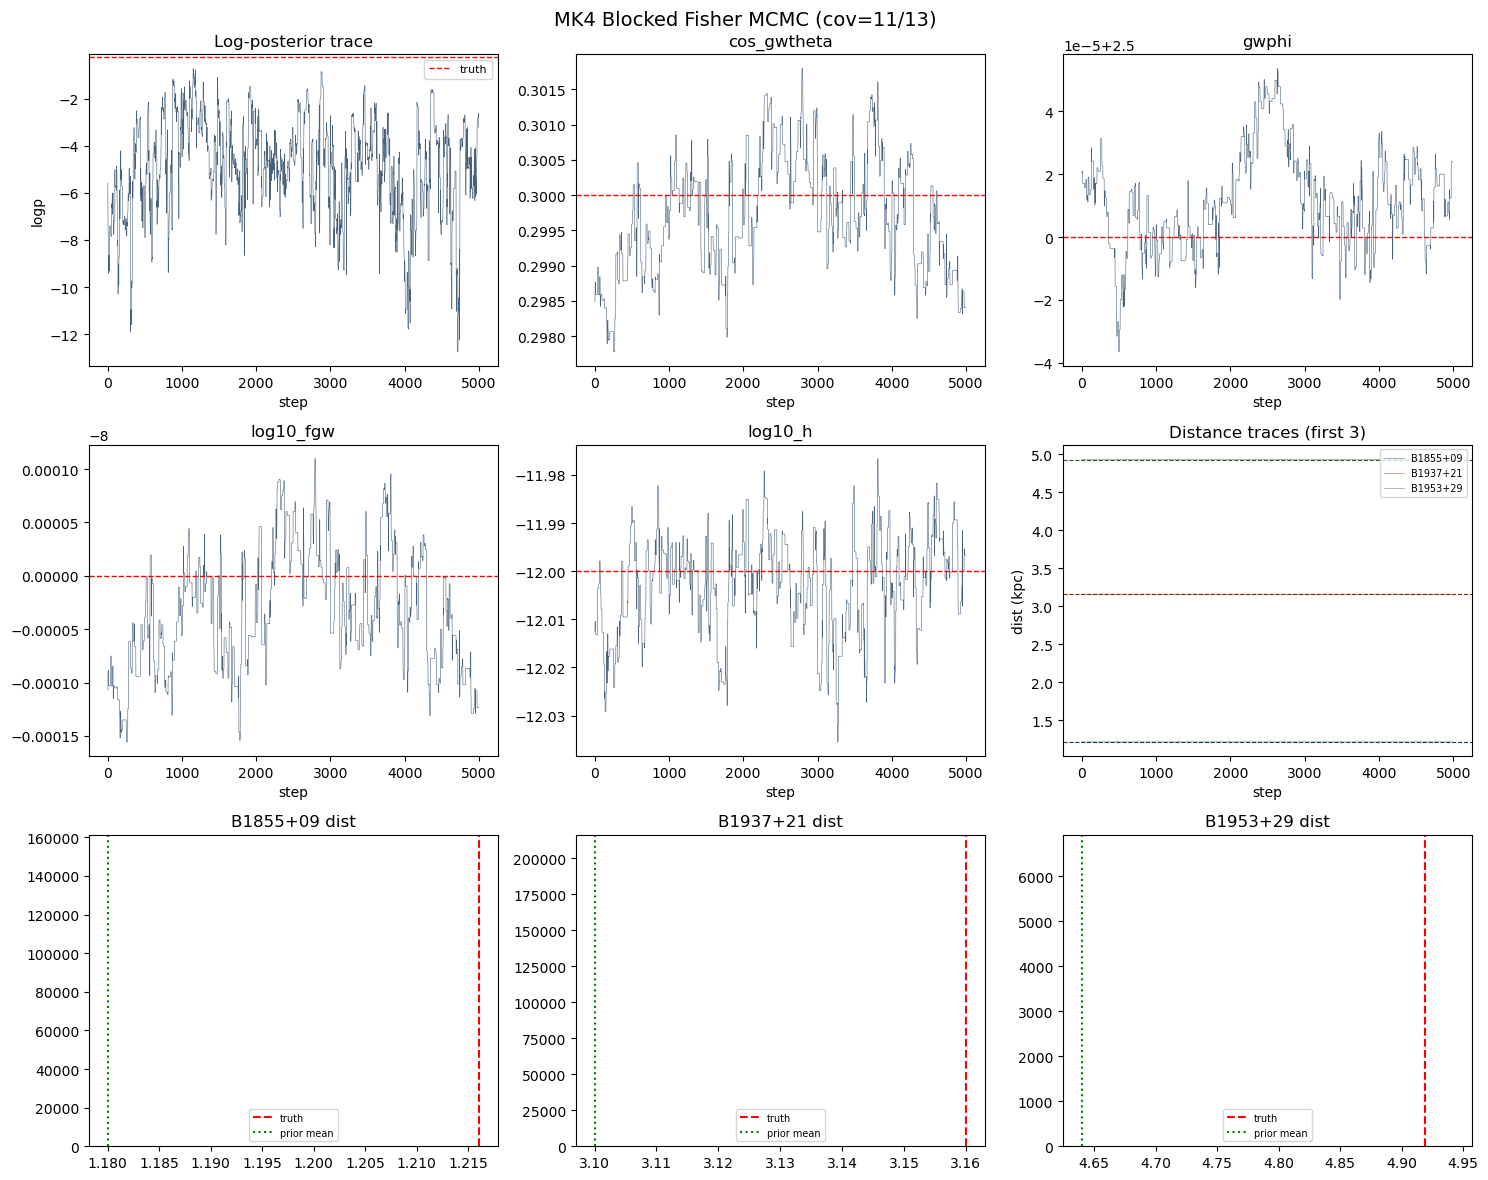


SUMMARY: cov=11/13, ESS=[7, 66]
CW Fisher AR: 0.2330
Dist within AR: 0.7096
Dist big AR: 0.0019


In [7]:
# ============================================================
# Diagnostics
# ============================================================
cw_keys = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
           'log10_fgw', 'log10_h', 'phase0', 'psi']

# Coverage
cov = sum(1 for k in range(13)
          if np.percentile(chain[:,k],5) <= p5_truth[k] <= np.percentile(chain[:,k],95))
print(f"Coverage: {cov}/13")

# ESS
ess_vals = {pnames_13[k]: ess_1d(chain[:,k]) for k in range(13)}
print(f"ESS range: [{min(ess_vals.values()):.0f}, {max(ess_vals.values()):.0f}]")
for k, v in ess_vals.items():
    print(f"  {k:20s}: ESS={v:.0f}")

# Distance errors
print(f"\nDistance errors:")
for j in range(Npulsars):
    med = np.median(chain[:, 8+j])
    err_dL = abs(med - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name:13s}: median={med:.6f}, truth={p5_truth[8+j]:.6f}, "
          f"err={err_dL:.1f} dL")

# --- Plots ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'MK4 Blocked Fisher MCMC (cov={cov}/13)', fontsize=14)

# logp trace
ax = axes[0, 0]
ax.plot(lps_chain, color='#1a3a5c', lw=0.4, alpha=0.8)
ax.axhline(lp_truth, color='r', ls='--', lw=1, label='truth')
ax.set_xlabel('step'); ax.set_ylabel('logp')
ax.set_title('Log-posterior trace'); ax.legend(fontsize=8)

# CW param traces (first 4)
for i, idx in enumerate([0, 1, 4, 5]):
    ax = axes[0, 1] if i == 0 else axes[0, 2] if i == 1 else axes[1, 0] if i == 2 else axes[1, 1]
    ax.plot(chain[:, idx], color='#1a3a5c', lw=0.4, alpha=0.8)
    ax.axhline(p5_truth[idx], color='r', ls='--', lw=1)
    ax.set_title(cw_keys[idx]); ax.set_xlabel('step')

# Distance traces
ax = axes[1, 2]
colours = ['#1a3a5c', '#8b2500', '#2d5a27']
for j in range(min(3, Npulsars)):
    ax.plot(chain[:, 8+j], alpha=0.7, lw=0.4, color=colours[j], label=disco_psrs[j].name[:8])
    ax.axhline(p5_truth[8+j], color=colours[j], ls='--', lw=0.8)
ax.set_xlabel('step'); ax.set_ylabel('dist (kpc)')
ax.set_title('Distance traces (first 3)'); ax.legend(fontsize=7)

# Distance posteriors vs priors
for j in range(min(3, Npulsars)):
    ax = axes[2, j]
    ax.hist(chain[:, 8+j], bins=80, density=True, alpha=0.7, color='#2b5797')
    ax.axvline(p5_truth[8+j], color='r', ls='--', lw=1.5, label='truth')
    ax.axvline(float(dist_mu[j]), color='green', ls=':', lw=1.5, label='prior mean')
    ax.set_title(f'{disco_psrs[j].name[:8]} dist'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# Summary
print(f"\n{'='*60}")
print(f"SUMMARY: cov={cov}/13, ESS=[{min(ess_vals.values()):.0f}, {max(ess_vals.values()):.0f}]")
print(f"CW Fisher AR: {ar['cw_fisher']:.4f}")
print(f"Dist within AR: {ar['dist_within']:.4f}")
print(f"Dist big AR: {ar['dist_big']:.4f}")
print(f"{'='*60}")

In [8]:
# ============================================================
# Test 2: Hessian at a DIFFERENT mode peak vs truth
#
# Key improvements over previous attempt:
#   1. Shift by integer dL, then snap to the actual nearest
#      peak via a fine 1D grid search per pulsar
#   2. Keep shifted distances within 2-sigma of the EM prior
#      (these are EM-informed, unlikely to be wildly wrong)
# ============================================================
rng_shift = np.random.default_rng(123)

def snap_to_peak(x13, pulsar_idx):
    """Find the nearest mode peak for one pulsar via fine 1D scan."""
    j = pulsar_idx
    d_center = x13[8+j]
    dL_j = float(dL_truth[j])
    # Scan +/- 0.6 dL around the shifted point (covers one full mode)
    d_candidates = np.linspace(d_center - 0.6*dL_j, d_center + 0.6*dL_j, 200)
    d_candidates = d_candidates[d_candidates > 1e-6]

    x_test = np.tile(x13, (len(d_candidates), 1))
    x_test[:, 8+j] = d_candidates
    lps_scan = np.array(jax.vmap(logp)(jnp.array(x_test)))
    best_idx = np.argmax(lps_scan)
    return float(d_candidates[best_idx])

# Shift distances by small integer modes, staying within ~2 sigma of prior
print("Shifting distances to nearby mode peaks within 2-sigma of prior...")
x_shifted = p5_truth.copy()
mode_offsets = []
for j in range(Npulsars):
    mu_j = float(dist_mu[j])
    sig_j = float(dist_sig[j])
    dL_j = dL_truth[j]

    # Max modes we can shift while staying within 2-sigma
    max_modes_up = int((mu_j + 2*sig_j - p5_truth[8+j]) / dL_j)
    max_modes_dn = int((p5_truth[8+j] - max(mu_j - 2*sig_j, dL_j)) / dL_j)
    # Pick a random shift (at least 3 modes if possible)
    lo = min(-max_modes_dn, -3)
    hi = max(max_modes_up, 3)
    n_shift = rng_shift.integers(lo, hi+1)
    if n_shift == 0:
        n_shift = rng_shift.choice([-3, 3])

    x_shifted[8+j] += n_shift * dL_j
    # Clamp to [dL_j, mu + 2*sigma]
    x_shifted[8+j] = np.clip(x_shifted[8+j], dL_j, mu_j + 2*sig_j)
    mode_offsets.append(n_shift)

print(f"\nBefore snapping:")
for j in range(Npulsars):
    d_shift = x_shifted[8+j] - p5_truth[8+j]
    nsig = (x_shifted[8+j] - float(dist_mu[j])) / float(dist_sig[j])
    print(f"  {disco_psrs[j].name}: d={x_shifted[8+j]:.6f} "
          f"({mode_offsets[j]:+d} modes, {nsig:+.2f} sigma from prior mean)")

lp_before_snap = float(logp(jnp.array(x_shifted)))
print(f"\n  logp before snap = {lp_before_snap:.2f}")

# Snap each distance to the nearest actual mode peak
print(f"\nSnapping to nearest mode peaks...")
for j in range(Npulsars):
    d_old = x_shifted[8+j]
    d_new = snap_to_peak(x_shifted, j)
    x_shifted[8+j] = d_new
    shift_frac = abs(d_new - d_old) / dL_truth[j]
    print(f"  {disco_psrs[j].name}: {d_old:.6f} -> {d_new:.6f} "
          f"(moved {shift_frac:.3f} dL to snap)")

lp_after_snap = float(logp(jnp.array(x_shifted)))
print(f"\n  logp(truth)      = {lp_truth:.2f}")
print(f"  logp(after snap) = {lp_after_snap:.2f}")
print(f"  Delta logp       = {lp_after_snap - lp_truth:.2f}")
print(f"  (should be small - just prior penalty from being on a different mode)")

# Compute Hessian at the snapped point
print(f"\nComputing Hessian at snapped point...")
t0 = time.time()
H_snapped = np.array(jax.hessian(logp)(jnp.array(x_shifted)))
dt = time.time() - t0
print(f"  Hessian computed in {dt:.1f}s")
print(f"  H finite: {np.all(np.isfinite(H_snapped))}")

# Compare CW 8x8 sub-blocks
H_cw_snapped = H_snapped[:8, :8]
cw_diff = np.abs(H_cw - H_cw_snapped)
cw_rel_diff = cw_diff / (np.abs(H_cw) + 1e-30)

print(f"\n--- CW 8x8 block comparison ---")
print(f"  Max absolute diff: {cw_diff.max():.2e}")
print(f"  Max relative diff: {cw_rel_diff.max():.4f}")
print(f"  Mean relative diff: {cw_rel_diff.mean():.4f}")

# Compare distance diagonals
print(f"\n--- Distance diagonal comparison ---")
print(f"  {'Pulsar':13s} {'H_truth':>12s} {'H_snapped':>12s} {'rel_diff':>10s}")
for j in range(Npulsars):
    h_t = H_full[8+j, 8+j]
    h_s = H_snapped[8+j, 8+j]
    rd = abs(h_t - h_s) / (abs(h_t) + 1e-30)
    print(f"  {disco_psrs[j].name:13s} {h_t:12.2e} {h_s:12.2e} {rd:10.4f}")

# Build proposal from snapped-point Hessian
neg_H_cw_s = -H_cw_snapped
eig_s, evec_s = np.linalg.eigh(neg_H_cw_s)
print(f"\n  CW block eigenvalues (snapped): {eig_s}")
print(f"  All positive: {np.all(eig_s > 0)}")
eig_s_c = np.maximum(eig_s, 1e-12 * eig_s.max())
cov_cw_s = evec_s @ np.diag(1.0 / eig_s_c) @ evec_s.T
cov_cw_s = 0.5 * (cov_cw_s + cov_cw_s.T)
L_cw_snapped = np.linalg.cholesky(scale_cw * cov_cw_s)

dist_fisher_sig_snapped = np.zeros(Npulsars)
for j in range(Npulsars):
    neg_hess_jj = -H_snapped[8+j, 8+j]
    if neg_hess_jj > 0:
        dist_fisher_sig_snapped[j] = 1.0 / np.sqrt(neg_hess_jj)
    else:
        dist_fisher_sig_snapped[j] = dL_truth[j] * 0.3

# Compare proposal Cholesky diagonals
print(f"\n--- Proposal Cholesky diagonal comparison ---")
print(f"  {'Param':15s} {'L_truth':>12s} {'L_snapped':>12s} {'rel_diff':>10s}")
for i in range(8):
    lt = np.diag(L_cw)[i]
    ls = np.diag(L_cw_snapped)[i]
    rd = abs(lt - ls) / (abs(lt) + 1e-30)
    label = ['cos_gwth','gwphi','cos_inc','log10_mc','log10_fgw','log10_h','phase0','psi'][i]
    print(f"  {label:15s} {lt:12.6f} {ls:12.6f} {rd:10.4f}")
print(f"\n  {'Dist Fisher sig':15s} {'truth':>12s} {'snapped':>12s} {'rel_diff':>10s}")
for j in range(Npulsars):
    rd = abs(dist_fisher_sig[j] - dist_fisher_sig_snapped[j]) / (dist_fisher_sig[j] + 1e-30)
    print(f"  {disco_psrs[j].name:15s} {dist_fisher_sig[j]:12.6f} "
          f"{dist_fisher_sig_snapped[j]:12.6f} {rd:10.4f}")

print(f"\nConclusion: if rel_diffs are small (<~0.1), "
      f"Fisher info is mode-invariant and can be computed at any mode peak.")

Shifting distances to nearby mode peaks within 2-sigma of prior...

Before snapping:
  B1855+09: d=0.947033 (-464 modes, -1.94 sigma from prior mean)
  B1937+21: d=3.245641 (+147 modes, +0.73 sigma from prior mean)
  B1953+29: d=4.985928 (+111 modes, +0.37 sigma from prior mean)
  J0023+0923: d=0.823709 (-388 modes, -1.78 sigma from prior mean)
  J0030+0451: d=0.335379 (+8 modes, +1.61 sigma from prior mean)

  logp before snap = -4200.85

Snapping to nearest mode peaks...
  B1855+09: 0.947033 -> 0.946860 (moved 0.298 dL to snap)
  B1937+21: 3.245641 -> 3.245784 (moved 0.244 dL to snap)
  B1953+29: 4.985928 -> 4.985708 (moved 0.365 dL to snap)
  J0023+0923: 0.823709 -> 0.823511 (moved 0.335 dL to snap)
  J0030+0451: 0.335379 -> 0.335448 (moved 0.118 dL to snap)

  logp(truth)      = -0.23
  logp(after snap) = -12.05
  Delta logp       = -11.82
  (should be small - just prior penalty from being on a different mode)

Computing Hessian at snapped point...
  Hessian computed in 0.3s
  H fi

Test 3: Start from snapped shifted point, snapped Hessian
  logp(snapped start) = -12.05
  Mode offsets: [np.int64(-464), np.int64(147), np.int64(111), np.int64(-388), np.int64(8)]
  B1855+09: start d=0.946860, err=464.3 dL from truth, -1.94 sigma from prior
  B1937+21: start d=3.245784, err=147.2 dL from truth, +0.73 sigma from prior
  B1953+29: start d=4.985708, err=110.6 dL from truth, +0.37 sigma from prior
  J0023+0923: start d=0.823511, err=388.3 dL from truth, -1.79 sigma from prior
  J0030+0451: start d=0.335448, err=8.1 dL from truth, +1.62 sigma from prior
  [burn 1000/7000] lp=-16.18  AR: cw_fisher=0.236  dist_within=0.687  dist_big=0.000  dist_small=0.031  cw_gibbs=0.503  [2531 it/s, ETA 2s]
  [prod 2000/7000] lp=-16.25  AR: cw_fisher=0.225  dist_within=0.688  dist_big=0.003  dist_small=0.040  cw_gibbs=0.500  [2419 it/s, ETA 2s]
  [prod 3000/7000] lp=-16.63  AR: cw_fisher=0.216  dist_within=0.699  dist_big=0.002  dist_small=0.039  cw_gibbs=0.482  [2523 it/s, ETA 2s]
  [prod

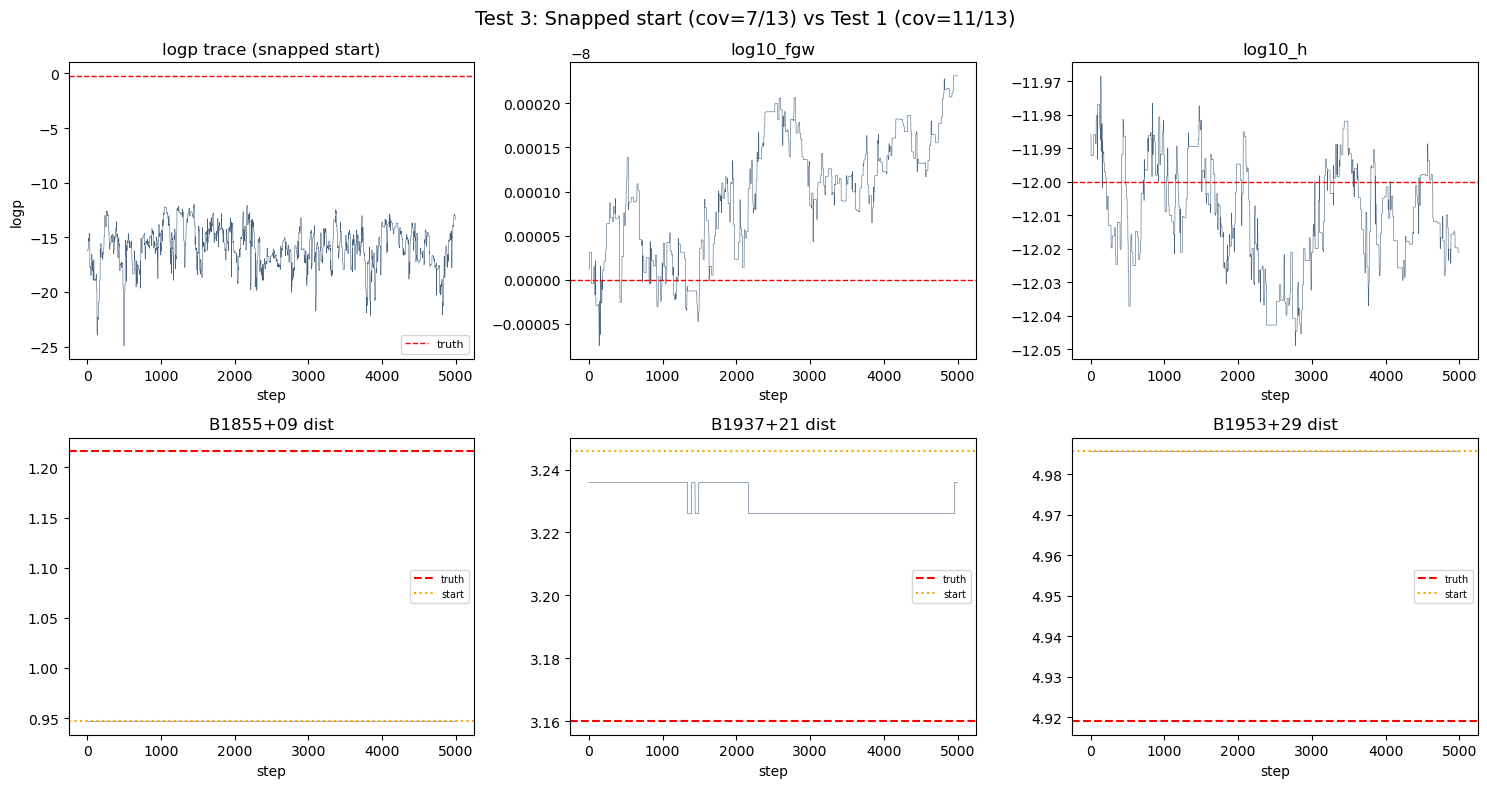

In [9]:
# ============================================================
# Test 3: Run sampler from snapped shifted point
# Uses Fisher computed at the wrong (but on-peak) mode
# ============================================================
print("Test 3: Start from snapped shifted point, snapped Hessian")
print(f"  logp(snapped start) = {lp_after_snap:.2f}")
print(f"  Mode offsets: {mode_offsets}")
for j in range(Npulsars):
    err_dL = abs(x_shifted[8+j] - p5_truth[8+j]) / dL_truth[j]
    nsig = (x_shifted[8+j] - float(dist_mu[j])) / float(dist_sig[j])
    print(f"  {disco_psrs[j].name}: start d={x_shifted[8+j]:.6f}, "
          f"err={err_dL:.1f} dL from truth, {nsig:+.2f} sigma from prior")

dL_snapped = np.array(compute_delta_L(
    x_shifted[0], x_shifted[1], x_shifted[4]))

chain2, lps2, ar2 = run_blocked_chain(
    logp, x_shifted.copy(), np.random.default_rng(42),
    L_cw=L_cw_snapped, dist_fisher_sig=dist_fisher_sig_snapped,
    dL_arr=dL_snapped,
    n_burn=2000, n_prod=5000, report_every=1000)

# Diagnostics
cov2 = sum(1 for k in range(13)
           if np.percentile(chain2[:,k],5) <= p5_truth[k] <= np.percentile(chain2[:,k],95))
ess2 = {pnames_13[k]: ess_1d(chain2[:,k]) for k in range(13)}

print(f"\n--- Test 3 Results ---")
print(f"Coverage: {cov2}/13")
print(f"ESS range: [{min(ess2.values()):.0f}, {max(ess2.values()):.0f}]")

print(f"\nDistance errors:")
for j in range(Npulsars):
    med = np.median(chain2[:, 8+j])
    err_dL = abs(med - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name:13s}: median={med:.6f}, truth={p5_truth[8+j]:.6f}, "
          f"err={err_dL:.1f} dL (started {mode_offsets[j]:+d} modes away)")

# --- Side-by-side comparison ---
print(f"\n{'='*70}")
print(f"{'':20s} {'Test 1 (truth)':>18s} {'Test 3 (snapped)':>18s}")
print(f"{'='*70}")
print(f"{'Coverage':20s} {cov:>13d}/13   {cov2:>13d}/13")
print(f"{'ESS min':20s} {min(ess_vals.values()):>16.0f}   {min(ess2.values()):>16.0f}")
print(f"{'ESS max':20s} {max(ess_vals.values()):>16.0f}   {max(ess2.values()):>16.0f}")
print(f"{'CW Fisher AR':20s} {ar['cw_fisher']:>16.4f}   {ar2['cw_fisher']:>16.4f}")
print(f"{'Dist within AR':20s} {ar['dist_within']:>16.4f}   {ar2['dist_within']:>16.4f}")
print(f"{'Dist big AR':20s} {ar['dist_big']:>16.4f}   {ar2['dist_big']:>16.4f}")
print(f"{'='*70}")

# Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Test 3: Snapped start (cov={cov2}/13) vs Test 1 (cov={cov}/13)', fontsize=14)

ax = axes[0, 0]
ax.plot(lps2, color='#1a3a5c', lw=0.4, alpha=0.8)
ax.axhline(lp_truth, color='r', ls='--', lw=1, label='truth')
ax.set_xlabel('step'); ax.set_ylabel('logp')
ax.set_title('logp trace (snapped start)'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(chain2[:, 4], color='#1a3a5c', lw=0.4, alpha=0.8)
ax.axhline(p5_truth[4], color='r', ls='--', lw=1)
ax.set_title('log10_fgw'); ax.set_xlabel('step')

ax = axes[0, 2]
ax.plot(chain2[:, 5], color='#1a3a5c', lw=0.4, alpha=0.8)
ax.axhline(p5_truth[5], color='r', ls='--', lw=1)
ax.set_title('log10_h'); ax.set_xlabel('step')

for j in range(min(3, Npulsars)):
    ax = axes[1, j]
    ax.plot(chain2[:, 8+j], color='#1a3a5c', lw=0.4, alpha=0.8)
    ax.axhline(p5_truth[8+j], color='r', ls='--', lw=1.5, label='truth')
    ax.axhline(x_shifted[8+j], color='orange', ls=':', lw=1.5, label='start')
    ax.set_title(f'{disco_psrs[j].name[:8]} dist')
    ax.set_xlabel('step'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

In [10]:
# ============================================================
# Test 4: Three big-jump strategies head-to-head
#
# All three replace the old uniform(1,20) big-jump move.
# We run each independently from the SAME shifted start so
# the comparison is fair.
#
# Approach 1: Log-uniform mode count (heavier tails)
#   Draw n_modes ~ exp(uniform(0, log(max_modes))).
#   Can jump 1 to ~500 modes in one step.
#
# Approach 2: Prior-draw + snap
#   Draw d_new ~ N(mu, sigma), snap to nearest peak.
#   Naturally targets the prior-supported region.
#
# Approach 3: 1D profile scan (independence sampler)
#   Scan N candidates within prior, evaluate per-pulsar LL,
#   pick proportional to exp(ll + prior). Most expensive but
#   most informed.
# ============================================================

# --- Per-pulsar LL for approaches 2 & 3 ---
def per_psr_ll_at_dist(x13, pi, d_candidates):
    """Evaluate per-pulsar log-likelihood at many distance candidates.
    Returns array of shape (len(d_candidates),)."""
    x_batch = np.tile(x13, (len(d_candidates), 1))
    x_batch[:, 8+pi] = d_candidates
    # Full logp includes all pulsars, but we only vary one distance.
    # This is correct for MH acceptance since other pulsars contribute
    # the same constant to both current and proposed.
    lps_batch = np.array(jax.vmap(logp)(jnp.array(x_batch)))
    return lps_batch

def snap_to_peak_at(x13, pi, d_center, dL_j, n_pts=50):
    """Snap to nearest peak within +/-0.6 dL of d_center."""
    d_lo = max(d_center - 0.6*dL_j, 1e-6)
    d_hi = d_center + 0.6*dL_j
    d_cands = np.linspace(d_lo, d_hi, n_pts)
    lps = per_psr_ll_at_dist(x13, pi, d_cands)
    return float(d_cands[np.argmax(lps)])

def run_bigjump_test(logp_fn, x0, rng, L_cw, dist_fisher_sig, dL_arr,
                     approach='loguniform', n_burn=2000, n_prod=5000,
                     report_every=2000, scan_n_candidates=200):
    """Blocked sampler with a specific big-jump strategy.
    approach: 'loguniform', 'prior_snap', or 'profile_scan'
    """
    D = len(x0)
    Npsr = D - 8
    x = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))

    chain = np.zeros((n_prod, D))
    lps_out = np.zeros(n_prod)

    acc = {'cw_fisher': 0, 'dist_within': 0, 'big_jump': 0,
           'dist_small': 0, 'cw_gibbs': 0}
    tot = {k: 0 for k in acc}
    cw_gibbs_sig = np.diag(L_cw).copy()

    # Pre-compute prior arrays
    mu_arr = np.array([float(dist_mu[j]) for j in range(Npsr)])
    sig_arr = np.array([float(dist_sig[j]) for j in range(Npsr)])

    # For profile scan: pre-compute candidate grids per pulsar (within 3-sigma)
    if approach == 'profile_scan':
        scan_grids = []
        for j in range(Npsr):
            d_lo = max(mu_arr[j] - 3*sig_arr[j], float(dL_arr[j]))
            d_hi = mu_arr[j] + 3*sig_arr[j]
            scan_grids.append(np.linspace(d_lo, d_hi, scan_n_candidates))

    total_steps = n_burn + n_prod
    t0 = time.time()

    for step in range(-n_burn, n_prod):
        r = rng.random()

        if r < 0.35:
            # CW-only 8D Fisher
            z = rng.standard_normal(8)
            x_prop = x.copy()
            x_prop[:8] += L_cw @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_fisher'] += 1
            tot['cw_fisher'] += 1

        elif r < 0.50:
            # Within-mode distance refinement
            pi = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1

        elif r < 0.75:
            # === BIG JUMP (approach-specific) ===
            pi = rng.integers(Npsr)

            if approach == 'loguniform':
                # Log-uniform mode count: can jump 1 to max_modes
                max_modes = max(int(2 * sig_arr[pi] / float(dL_arr[pi])), 20)
                n_modes = int(np.exp(rng.uniform(0, np.log(max_modes + 1))))
                n_modes = max(n_modes, 1)
                sign = rng.choice([-1, 1])
                x_prop = x.copy()
                x_prop[8+pi] += sign * n_modes * float(dL_arr[pi])
                if x_prop[8+pi] > 1e-6:
                    lp_prop = float(logp_fn(jnp.array(x_prop)))
                    if np.log(rng.random() + 1e-300) < lp_prop - lp:
                        x = x_prop; lp = lp_prop; acc['big_jump'] += 1

            elif approach == 'prior_snap':
                # Draw from prior, snap to nearest peak
                d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
                if d_prop > float(dL_arr[pi]):
                    d_snapped = snap_to_peak_at(x, pi, d_prop, float(dL_arr[pi]))
                    x_prop = x.copy()
                    x_prop[8+pi] = d_snapped
                    lp_prop = float(logp_fn(jnp.array(x_prop)))
                    if np.log(rng.random() + 1e-300) < lp_prop - lp:
                        x = x_prop; lp = lp_prop; acc['big_jump'] += 1

            elif approach == 'profile_scan':
                # Scan candidates, sample proportional to posterior
                d_cands = scan_grids[pi]
                lps_cands = per_psr_ll_at_dist(x, pi, d_cands)
                # Numerical stability
                lps_cands_safe = lps_cands - np.max(lps_cands)
                weights = np.exp(lps_cands_safe)
                weights_sum = weights.sum()
                if weights_sum > 0:
                    probs = weights / weights_sum
                    # Sample from the scanned profile
                    idx_prop = rng.choice(len(d_cands), p=probs)
                    d_prop = d_cands[idx_prop]
                    # MH correction for independence sampler:
                    # q(x'|x) = probs[idx_prop], q(x|x') = prob of current
                    # Find probability of current distance in the grid
                    idx_cur = np.argmin(np.abs(d_cands - x[8+pi]))
                    log_q_prop = np.log(probs[idx_prop] + 1e-300)
                    log_q_cur = np.log(probs[idx_cur] + 1e-300)
                    x_prop = x.copy()
                    x_prop[8+pi] = d_prop
                    lp_prop = float(logp_fn(jnp.array(x_prop)))
                    # MH ratio: (p(x')/q(x')) / (p(x)/q(x))
                    log_alpha = (lp_prop - log_q_prop) - (lp - log_q_cur)
                    if np.log(rng.random() + 1e-300) < log_alpha:
                        x = x_prop; lp = lp_prop; acc['big_jump'] += 1

            tot['big_jump'] += 1

        elif r < 0.87:
            # Small distance perturbation
            pi = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += 0.3 * float(dL_arr[pi]) * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_small'] += 1
            tot['dist_small'] += 1

        else:
            # Single CW param Gibbs
            idx = rng.integers(8)
            x_prop = x.copy()
            x_prop[idx] += cw_gibbs_sig[idx] * rng.standard_normal()
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_gibbs'] += 1
            tot['cw_gibbs'] += 1

        if step >= 0:
            chain[step] = x
            lps_out[step] = lp

        abs_step = step + n_burn
        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))
            # Update scan grids if profile_scan
            if approach == 'profile_scan':
                for j in range(Npsr):
                    d_lo = max(mu_arr[j] - 3*sig_arr[j], float(dL_arr[j]))
                    d_hi = mu_arr[j] + 3*sig_arr[j]
                    scan_grids[j] = np.linspace(d_lo, d_hi, scan_n_candidates)

        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate = abs_step / elapsed
            eta = (total_steps - abs_step) / rate
            ar_bj = acc['big_jump'] / max(tot['big_jump'], 1)
            ar_cw = acc['cw_fisher'] / max(tot['cw_fisher'], 1)
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f} "
                  f"CW_AR={ar_cw:.3f} BJ_AR={ar_bj:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")

    dt_total = time.time() - t0
    ar_dict = {k: acc[k]/max(tot[k],1) for k in acc}
    print(f"\n  {approach}: {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"    {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    return chain, lps_out, ar_dict, dt_total

print("Big-jump test sampler defined")

Big-jump test sampler defined


Starting point: logp = -12.05
  B1855+09: err = 464 dL from truth
  B1937+21: err = 147 dL from truth
  B1953+29: err = 111 dL from truth
  J0023+0923: err = 388 dL from truth
  J0030+0451: err = 8 dL from truth

Running: loguniform
  [prod 2000/7000] lp=-14.04 CW_AR=0.106 BJ_AR=0.018 [2415 it/s, ETA 2s]
  [prod 4000/7000] lp=-11.15 CW_AR=0.098 BJ_AR=0.015 [2430 it/s, ETA 1s]
  [prod 6000/7000] lp=-11.00 CW_AR=0.112 BJ_AR=0.014 [2566 it/s, ETA 0s]

  loguniform: 2.7s (2626 it/s)
    cw_fisher      :    274/  2477 = 0.1106
    dist_within    :    710/  1014 = 0.7002
    big_jump       :     24/  1743 = 0.0138
    dist_small     :     19/   873 = 0.0218
    cw_gibbs       :    434/   893 = 0.4860

Running: prior_snap
  [prod 2000/7000] lp=-4.36 CW_AR=0.108 BJ_AR=0.456 [1107 it/s, ETA 5s]
  [prod 4000/7000] lp=-6.51 CW_AR=0.100 BJ_AR=0.459 [1324 it/s, ETA 2s]
  [prod 6000/7000] lp=-11.10 CW_AR=0.103 BJ_AR=0.449 [1424 it/s, ETA 1s]

  prior_snap: 4.8s (1456 it/s)
    cw_fisher      :    26

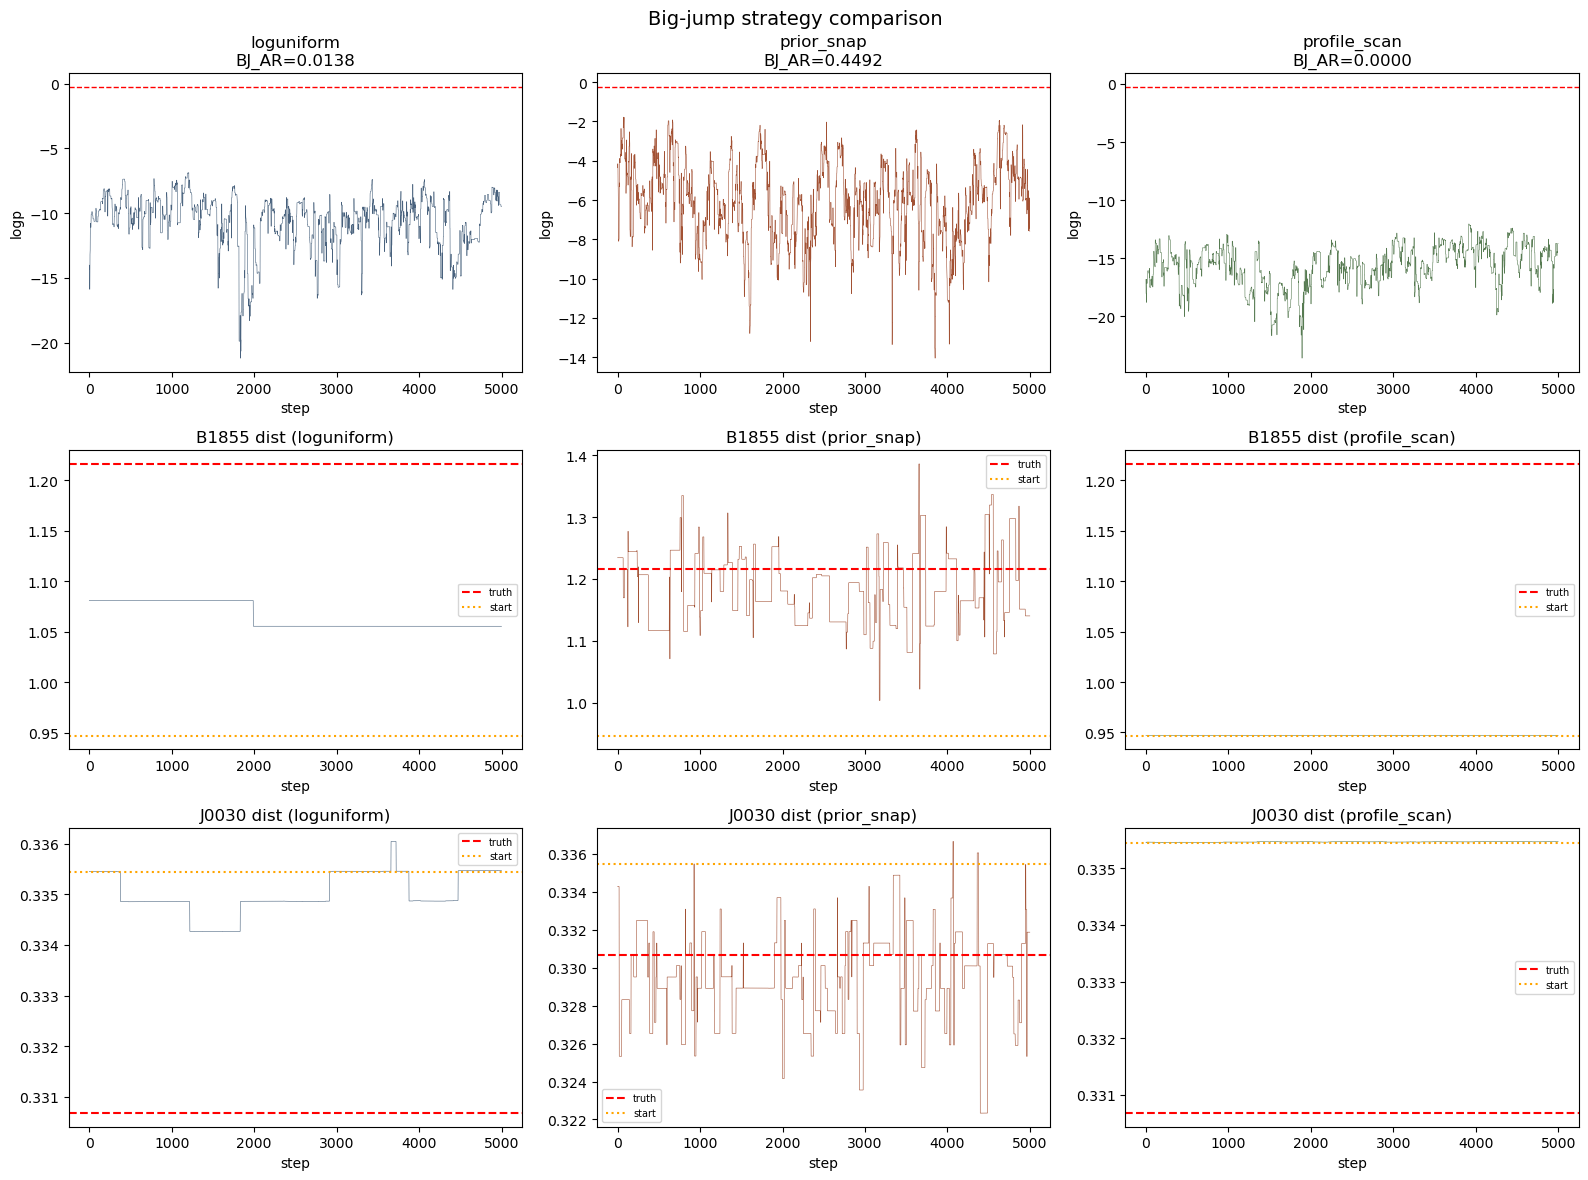

In [11]:
# ============================================================
# Run all three approaches from the same shifted start
# ============================================================
approaches = ['loguniform', 'prior_snap', 'profile_scan']
results = {}

# Use the snapped shifted point from Test 2 as start
x0_test = x_shifted.copy()
dL_test = np.array(compute_delta_L(x0_test[0], x0_test[1], x0_test[4]))
print(f"Starting point: logp = {float(logp(jnp.array(x0_test))):.2f}")
for j in range(Npulsars):
    err = abs(x0_test[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name}: err = {err:.0f} dL from truth")

for approach in approaches:
    print(f"\n{'='*60}")
    print(f"Running: {approach}")
    print(f"{'='*60}")
    ch, lp_ch, ar_ch, dt_ch = run_bigjump_test(
        logp, x0_test.copy(), np.random.default_rng(42),
        L_cw=L_cw, dist_fisher_sig=dist_fisher_sig,
        dL_arr=dL_test.copy(), approach=approach,
        n_burn=2000, n_prod=5000, report_every=2000,
        scan_n_candidates=200)
    
    cov_ch = sum(1 for k in range(13)
                 if np.percentile(ch[:,k],5) <= p5_truth[k] <= np.percentile(ch[:,k],95))
    ess_ch = {pnames_13[k]: ess_1d(ch[:,k]) for k in range(13)}
    d_err = [abs(np.median(ch[:,8+j]) - p5_truth[8+j]) / dL_truth[j] for j in range(Npulsars)]
    
    results[approach] = dict(chain=ch, lps=lp_ch, ar=ar_ch, dt=dt_ch,
                             cov=cov_ch, ess=ess_ch, d_err=d_err)

# ============================================================
# Comparison table
# ============================================================
print(f"\n\n{'='*80}")
print(f"BIG-JUMP STRATEGY COMPARISON")
print(f"{'='*80}")
print(f"{'Metric':25s}", end='')
for a in approaches:
    print(f" {a:>16s}", end='')
print()
print('-'*80)

print(f"{'Big jump AR':25s}", end='')
for a in approaches:
    print(f" {results[a]['ar']['big_jump']:>16.4f}", end='')
print()

print(f"{'CW Fisher AR':25s}", end='')
for a in approaches:
    print(f" {results[a]['ar']['cw_fisher']:>16.4f}", end='')
print()

print(f"{'Coverage (/13)':25s}", end='')
for a in approaches:
    print(f" {results[a]['cov']:>16d}", end='')
print()

print(f"{'ESS min':25s}", end='')
for a in approaches:
    print(f" {min(results[a]['ess'].values()):>16.0f}", end='')
print()

print(f"{'ESS max':25s}", end='')
for a in approaches:
    print(f" {max(results[a]['ess'].values()):>16.0f}", end='')
print()

print(f"{'Mean dist err (dL)':25s}", end='')
for a in approaches:
    print(f" {np.mean(results[a]['d_err']):>16.1f}", end='')
print()

print(f"{'Time (s)':25s}", end='')
for a in approaches:
    print(f" {results[a]['dt']:>16.1f}", end='')
print()

print(f"{'Speed (it/s)':25s}", end='')
for a in approaches:
    print(f" {7000/results[a]['dt']:>16.0f}", end='')
print()
print('='*80)

# Per-pulsar distance errors
print(f"\nPer-pulsar distance errors (dL from truth):")
print(f"  {'Pulsar':13s}", end='')
for a in approaches:
    print(f" {a:>16s}", end='')
print()
for j in range(Npulsars):
    print(f"  {disco_psrs[j].name:13s}", end='')
    for a in approaches:
        print(f" {results[a]['d_err'][j]:>16.1f}", end='')
    print()

# ============================================================
# Plots
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Big-jump strategy comparison', fontsize=14)
colors = {'loguniform': '#1a3a5c', 'prior_snap': '#8b2500', 'profile_scan': '#2d5a27'}

# Row 1: logp traces
for i, a in enumerate(approaches):
    ax = axes[0, i]
    ax.plot(results[a]['lps'], color=colors[a], lw=0.4, alpha=0.8)
    ax.axhline(lp_truth, color='r', ls='--', lw=1)
    ax.set_title(f'{a}\nBJ_AR={results[a]["ar"]["big_jump"]:.4f}')
    ax.set_xlabel('step'); ax.set_ylabel('logp')

# Row 2: Distance traces for hardest pulsar (B1855, idx=0)
for i, a in enumerate(approaches):
    ax = axes[1, i]
    ax.plot(results[a]['chain'][:, 8], color=colors[a], lw=0.4, alpha=0.8)
    ax.axhline(p5_truth[8], color='r', ls='--', lw=1.5, label='truth')
    ax.axhline(x0_test[8], color='orange', ls=':', lw=1.5, label='start')
    ax.set_title(f'B1855 dist ({a})')
    ax.set_xlabel('step'); ax.legend(fontsize=7)

# Row 3: Distance traces for J0030 (easiest, idx=4)
for i, a in enumerate(approaches):
    ax = axes[2, i]
    ax.plot(results[a]['chain'][:, 12], color=colors[a], lw=0.4, alpha=0.8)
    ax.axhline(p5_truth[12], color='r', ls='--', lw=1.5, label='truth')
    ax.axhline(x0_test[12], color='orange', ls=':', lw=1.5, label='start')
    ax.set_title(f'J0030 dist ({a})')
    ax.set_xlabel('step'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()